# **Reinforcement Learning project: Part 2**

## **Task 4 - Implementing PPO and SA**

### **project setup**
Let's start by setting up the environment for the project, we will be cloning the github repository and importing the necessary libraries for the tasks we will handle

In [1]:
# cloning the given github reporistory
!git clone https://github.com/lambdavi/FAIML-RL-26.git

%cd FAIML-RL-26/part2/panda-gym
!pip install -e .

%cd ..

fatal: destination path 'FAIML-RL-26' already exists and is not an empty directory.
/content/FAIML-RL-26/part2/panda-gym
Obtaining file:///content/FAIML-RL-26/part2/panda-gym
  Preparing metadata (setup.py) ... done
  Attempting uninstall: panda_gym
    Found existing installation: panda_gym 3.0.8
    Uninstalling panda_gym-3.0.8:
      Successfully uninstalled panda_gym-3.0.8
  Running setup.py develop for panda_gym
/content/FAIML-RL-26/part2


In [2]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


### **PPO algorithm implementation**
We will now begin by training the PPO algorithm. This code is inspired from the training code given in the Github repository. We will be adding a callback function along with the Monitor wrapper it requires to get some metrics from the training

#### **Training phase**


In [ ]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import PPO

# we will use the EvalCallback to collect the training data and plot it
# to do so the environment needs to be wrapped in the Monitor environment
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# initializing the environment for the robot
# render mode set to rgb_array because Colab does not support the display
# reward_type set to dense to give the model better insight on the reward,
# proportionally to the distance between pushed object and the target location
env = gym.make(
    "PandaPush-v3",
    render_mode="rgb_array",
    reward_type="dense",
)
env = Monitor(env)

# creating a CallBack instance to run some metrics in a separate environment
eval_env = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
eval_env = Monitor(eval_env)
eval_callback = EvalCallback(
    eval_env,
    eval_freq=1000,
    n_eval_episodes=5,
    log_path="./logs/",
    best_model_save_path="./best_model/",
    deterministic=True,
    verbose=1,
)

# creating an instance of the PPO algorithm and do training on selected env
model = PPO("MultiInputPolicy", env, verbose=1)
model.learn(total_timesteps=500000, callback= eval_callback)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
|    mean_ep_length       | 40.2        |
|    mean_reward          | -3.69       |
|    success_rate         | 0.2         |
| time/                   |             |
|    total_timesteps      | 277000      |
| train/                  |             |
|    approx_kl            | 0.008146478 |
|    clip_fraction        | 0.0873      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.42       |
|    explained_variance   | 0.989       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00893    |
|    n_updates            | 1350        |
|    policy_gradient_loss | -0.00776    |
|    std                  | 0.551       |
|    value_loss           | 0.0254      |
-----------------------------------------
Eval num_timesteps=278000, episode_reward=-5.11 +/- 0.51
Episode length: 50.00 +/- 0.00
Success rate: 0.00%
---------------------------------
| eval/              |  

#### **Using the callback**
now that the training is over, we can use the callback function we implemented during training to get a more visual result of how the training has been done

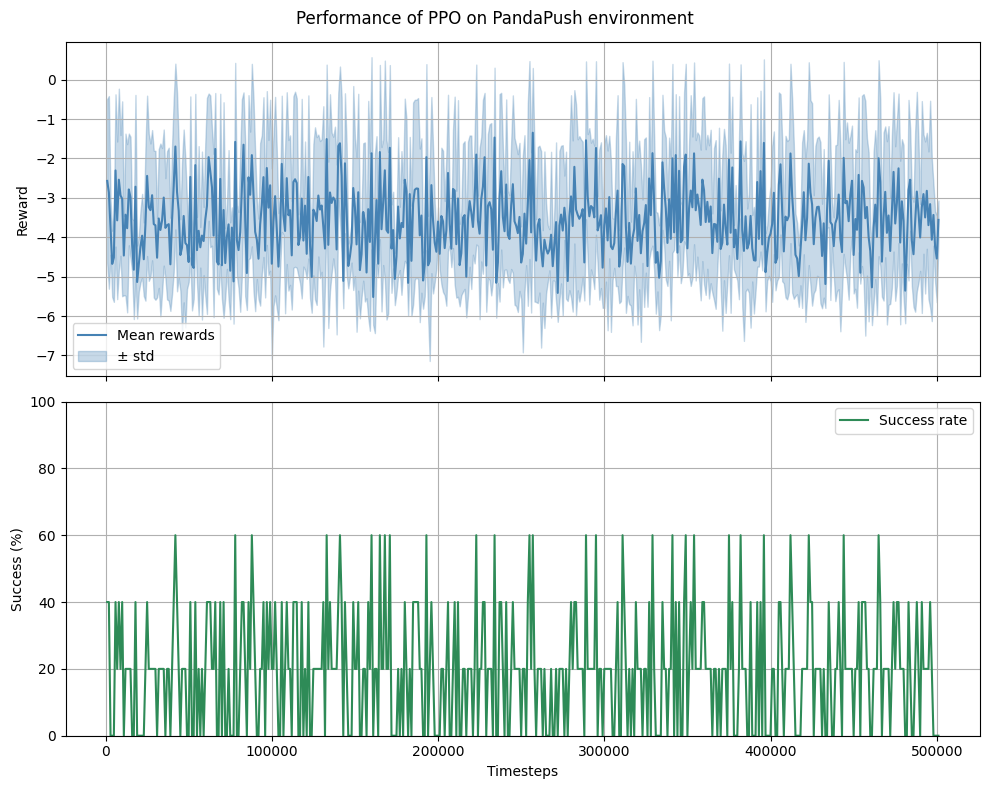

In [ ]:
# evaluating the performance of the model during its learning
import numpy as np
import matplotlib.pyplot as plt

# we first extract the relevant arrays:
# one for the steps during which an eval was done
# one for the reward of each evaluation episodes at every step an eval was done
# one for the sucess or not (0 or 1) of tasks during an evaluation at every step
rewards = eval_callback.evaluations_results
timesteps = eval_callback.evaluations_timesteps
successes = eval_callback.evaluations_successes

mean_rewards = np.mean(rewards, axis=1)
std_rewards  = np.std(rewards, axis=1)
mean_success = np.mean(successes, axis=1) * 100  # % of sucess in an evaluation

# plotting code
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Rewards are collected for each evaluation episode for each step (2d array)
# to do an easy to visualize plot, we can display mean and standard deviation
ax1.plot(timesteps, mean_rewards, color="steelblue", label="Mean rewards")
ax1.fill_between(timesteps,
                 mean_rewards - std_rewards,
                 mean_rewards + std_rewards,
                 alpha=0.3, color="steelblue", label="± std")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# Success rate
ax2.plot(timesteps, mean_success, color="seagreen", label="Success rate")
ax2.set_ylabel("Success (%)")
ax2.set_xlabel("Timesteps")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.suptitle("Performance of PPO on PandaPush environment")
plt.tight_layout()
plt.show()

#### **Model evaluation**
Let's now judge of the model trained in a testing environment. Again, this testing programme is based off the "eval_sb3.py" programme provided in the repository

In [ ]:
def evaluate(model, n_episodes=100, deterministic=True, env_type="source"):
    env = gym.make("PandaPush-v3", render_mode="rgb_array", type=env_type, reward_type="dense")

    episode_returns = []
    successes = []
    for episode in range(1, n_episodes + 1):
        obs, info = env.reset()
        terminated = False
        truncated = False
        episode_return = 0.0
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)
        episode_returns.append(episode_return)
        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))
        print(f"Episode {episode:03d} | return = {episode_return:.3f}")
    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes       : {n_episodes}")
    print(f"Mean return    : {returns.mean():.3f}")
    print(f"Std return     : {returns.std():.3f}")
    print(f"Min return     : {returns.min():.3f}")
    print(f"Max return     : {returns.max():.3f}")
    if successes:
        print(f"Success rate   : {float(np.mean(successes)):.2%}")

evaluate(model, n_episodes=100, deterministic=True, env_type="source")

Created object with mass: 1.0
Episode 001 | return = -3.254
Episode 002 | return = -0.039
Episode 003 | return = -3.734
Episode 004 | return = -6.347
Episode 005 | return = -2.817
Episode 006 | return = -6.470
Episode 007 | return = -3.921
Episode 008 | return = -4.591
Episode 009 | return = -3.389
Episode 010 | return = -0.026
Episode 011 | return = -3.076
Episode 012 | return = -0.049
Episode 013 | return = -6.243
Episode 014 | return = -0.032
Episode 015 | return = -4.988
Episode 016 | return = -2.960
Episode 017 | return = -5.064
Episode 018 | return = -5.261
Episode 019 | return = -4.779
Episode 020 | return = -5.072
Episode 021 | return = -3.713
Episode 022 | return = -5.259
Episode 023 | return = -0.043
Episode 024 | return = -4.749
Episode 025 | return = -5.040
Episode 026 | return = -0.014
Episode 027 | return = -3.526
Episode 028 | return = -4.263
Episode 029 | return = -5.256
Episode 030 | return = -0.029
Episode 031 | return = -0.039
Episode 032 | return = -0.032
Episode 03

Created object with mass: 1.0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


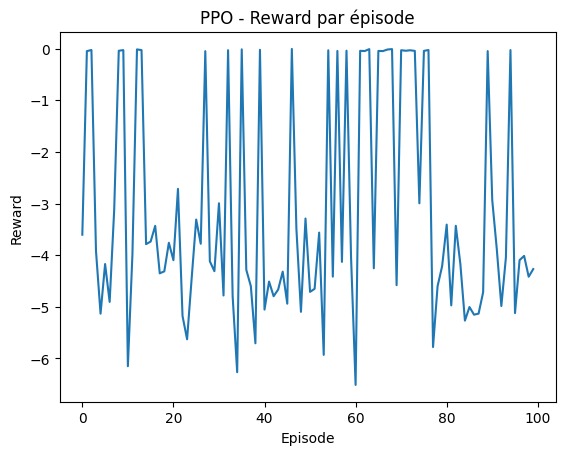

In [ ]:
from stable_baselines3.common.evaluation import evaluate_policy
eval_env_final = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
episode_rewards, episode_lengths = evaluate_policy(
    model, eval_env_final,
    n_eval_episodes=100,
    return_episode_rewards=True
)

import matplotlib.pyplot as plt
plt.plot(episode_rewards)
plt.title("PPO - Reward par épisode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

#### **Overall interpretation**

In regards of these results, the PPO algorithm seems to perform poorly in this task.
For the training phase, the expected result would be an overall increase of the sucess rate and a maximization of the reward function as we go on. However, we can see that the overall suces rate oscillates greatly around 30% and presents a significant variance. We can say the same thing of the reward function oscillating around -3 approximately wih a standard deviation of 2.5. No concergence seems to have been reached during this phase.

When it comes to the testing phase, the obtained values are close to those of the training phase. A huge variance can be observed as the model behaves more or less poorly across the different testing episodes.

This result indicates that, as an on-policy algorithm, PPO can only learn from data collected with its current policy, with no regards to any previous experience after each update. While this makes PPO stable and reliable in many settings, it makes it sample-inefficient — it requires a large number of interactions with the environment to converge. For a continuous control task like PandaPush, 200 000 steps is likely insufficient for PPO to find a good policy, which explains why no clear improvement is observed.

### **analysis of the training using the SAC algorithm**

In [3]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import SAC

# we will use the EvalCallback to collect the training data and plot it
# to do so the environment needs to be wrapped in the Monitor environment
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# initializing the environment for the robot
# render mode set to rgb_array because Colab does not support the display
# reward_type set to dense to give the model better insight on the reward,
# proportionally to the distance between pushed object and the target location
env = gym.make(
    "PandaPush-v3",
    render_mode="rgb_array",
    reward_type="dense",
)
env = Monitor(env)

# creating a CallBack instance to run some metrics in a separate environment
eval_env = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
eval_env = Monitor(eval_env)
eval_callback = EvalCallback(
    eval_env,
    eval_freq=1000,
    n_eval_episodes=5,
    log_path="./logs/",
    best_model_save_path="./best_model/",
    deterministic=True,
    verbose=1,
)

# creating an instance of the PPO algorithm and do training on selected env
model2 = SAC("MultiInputPolicy", env, verbose=1)
model2.learn(total_timesteps=500000, callback= eval_callback)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Created object with mass: 1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Created object with mass: 1.0
Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 37.8     |
|    ep_rew_mean     | -3.1     |
|    success_rate    | 0.25     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 65       |
|    time_elapsed    | 2        |
|    total_timesteps | 151      |
| train/             |          |
|    actor_loss      | -3.75    |
|    critic_loss     | 0.232    |
|    ent_coef        | 0.985    |
|    ent_coef_loss   | -0.0742  |
|    learning_rate   | 0.0003   |
|    n_updates       | 50       |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
|    success_rate    | 0.24     |
| time/              |          |
|    episodes        | 12272    |
|    fps             | 25       |
|    time_elapsed    | 17988    |
|    total_timesteps | 462586   |
| train/             |          |
|    actor_loss      | -11.6    |
|    critic_loss     | 5.29     |
|    ent_coef        | 0.0291   |
|    ent_coef_loss   | 0.134    |
|    learning_rate   | 0.0003   |
|    n_updates       | 462485   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 37.9     |
|    ep_rew_mean     | -3.68    |
|    success_rate    | 0.26     |
| time/              |          |
|    episodes        | 12276    |
|    fps             | 25       |
|    time_elapsed    | 17993    |
|    total_timesteps | 462688   |
| train/             |          |
|    actor_loss      | -12.3    |
|    critic_loss     | 14.6     |
|   

In [3]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import SAC

# we will use the EvalCallback to collect the training data and plot it
# to do so the environment needs to be wrapped in the Monitor environment
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# initializing the environment for the robot
# render mode set to rgb_array because Colab does not support the display
# reward_type set to dense to give the model better insight on the reward,
# proportionally to the distance between pushed object and the target location
env = gym.make(
    "PandaPush-v3",
    render_mode="rgb_array",
    reward_type="dense",
)
env = Monitor(env)

# creating a CallBack instance to run some metrics in a separate environment
eval_env = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
eval_env = Monitor(eval_env)
eval_callback = EvalCallback(
    eval_env,
    eval_freq=1000,
    n_eval_episodes=5,
    log_path="./logs/",
    best_model_save_path="./best_model/",
    deterministic=True,
    verbose=1,
)

# creating an instance of the PPO algorithm and do training on selected env
model2 = SAC("MultiInputPolicy", env, verbose=1)
model2.learn(total_timesteps=100000, callback= eval_callback)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Created object with mass: 1.0
Created object with mass: 1.0
Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
|    success_rate    | 0.17     |
| time/              |          |
|    episodes        | 1524     |
|    fps             | 28       |
|    time_elapsed    | 2162     |
|    total_timesteps | 62385    |
| train/             |          |
|    actor_loss      | 5.89     |
|    critic_loss     | 0.0223   |
|    ent_coef        | 0.00318  |
|    ent_coef_loss   | 2.35     |
|    learning_rate   | 0.0003   |
|    n_updates       | 62284    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 41.8     |
|    ep_rew_mean     | -3.64    |
|    success_rate    | 0.17     |
| time/              |          |
|    episodes        | 1528     |
|    fps             | 28       |
|    time_elapsed    | 2167     |
|    total_timesteps | 62536    |
| train/             |          |
|    actor_loss      | 5.89     |
|    critic_loss     | 0.115    |
|   

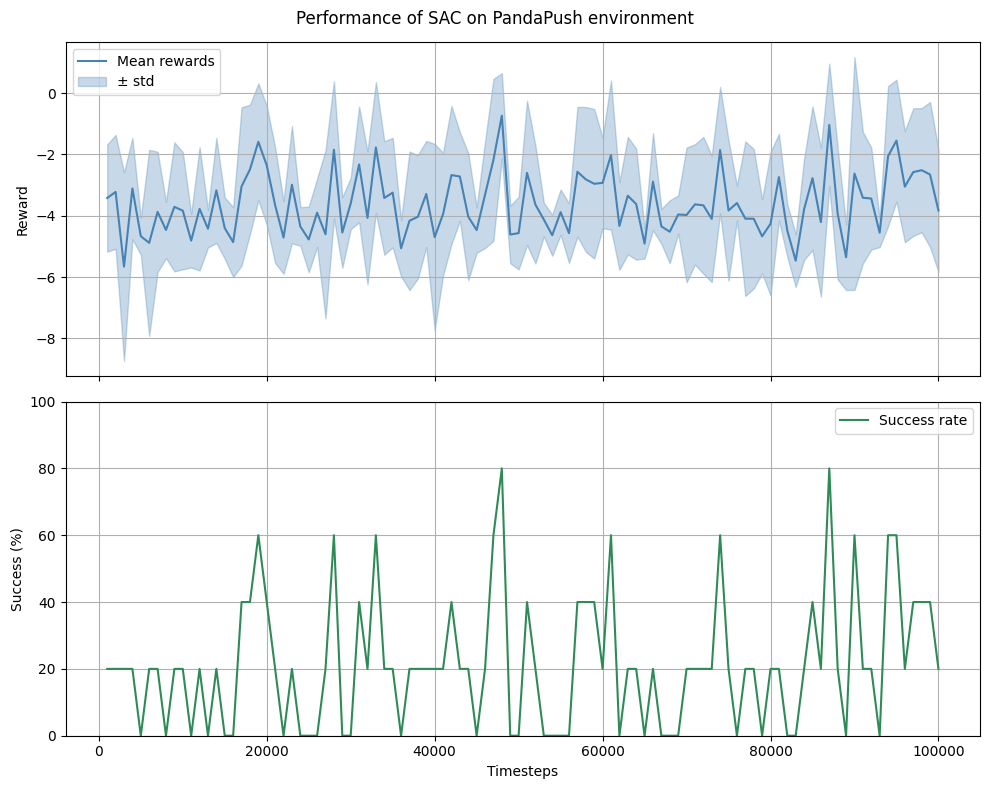

In [7]:
# evaluating the performance of the model during its learning
import numpy as np
import matplotlib.pyplot as plt

# we first extract the relevant arrays:
# one for the steps during which an eval was done
# one for the reward of each evaluation episodes at every step an eval was done
# one for the sucess or not (0 or 1) of tasks during an evaluation at every step
rewards = eval_callback.evaluations_results
timesteps = eval_callback.evaluations_timesteps
successes = eval_callback.evaluations_successes

mean_rewards = np.mean(rewards, axis=1)
std_rewards  = np.std(rewards, axis=1)
mean_success = np.mean(successes, axis=1) * 100  # % of sucess in an evaluation

# plotting code
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Rewards are collected for each evaluation episode for each step (2d array)
# to do an easy to visualize plot, we can display mean and standard deviation
ax1.plot(timesteps, mean_rewards, color="steelblue", label="Mean rewards")
ax1.fill_between(timesteps,
                 mean_rewards - std_rewards,
                 mean_rewards + std_rewards,
                 alpha=0.3, color="steelblue", label="± std")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# Success rate
ax2.plot(timesteps, mean_success, color="seagreen", label="Success rate")
ax2.set_ylabel("Success (%)")
ax2.set_xlabel("Timesteps")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.suptitle("Performance of SAC on PandaPush environment")
plt.tight_layout()
plt.show()

In [5]:
def evaluate(model, n_episodes=100, deterministic=True, env_type="source"):
    env = gym.make("PandaPush-v3", render_mode="rgb_array", type=env_type, reward_type="dense")

    episode_returns = []
    successes = []
    for episode in range(1, n_episodes + 1):
        obs, info = env.reset()
        terminated = False
        truncated = False
        episode_return = 0.0
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)
        episode_returns.append(episode_return)
        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))
        print(f"Episode {episode:03d} | return = {episode_return:.3f}")
    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes       : {n_episodes}")
    print(f"Mean return    : {returns.mean():.3f}")
    print(f"Std return     : {returns.std():.3f}")
    print(f"Min return     : {returns.min():.3f}")
    print(f"Max return     : {returns.max():.3f}")
    if successes:
        print(f"Success rate   : {float(np.mean(successes)):.2%}")

evaluate(model2, n_episodes=100, deterministic=True, env_type="source")

Created object with mass: 1.0
Episode 001 | return = -4.711
Episode 002 | return = -3.634
Episode 003 | return = -0.036
Episode 004 | return = -2.823
Episode 005 | return = -5.974
Episode 006 | return = -3.747
Episode 007 | return = -5.031
Episode 008 | return = -0.024
Episode 009 | return = -3.279
Episode 010 | return = -5.505
Episode 011 | return = -5.157
Episode 012 | return = -2.627
Episode 013 | return = -6.429
Episode 014 | return = -5.051
Episode 015 | return = -4.039
Episode 016 | return = -5.159
Episode 017 | return = -2.937
Episode 018 | return = -0.615
Episode 019 | return = -2.962
Episode 020 | return = -4.521
Episode 021 | return = -2.875
Episode 022 | return = -5.740
Episode 023 | return = -0.027
Episode 024 | return = -0.621
Episode 025 | return = -5.756
Episode 026 | return = -3.885
Episode 027 | return = -2.579
Episode 028 | return = -2.757
Episode 029 | return = -4.431
Episode 030 | return = -0.047
Episode 031 | return = -3.806
Episode 032 | return = -1.064
Episode 03

Created object with mass: 1.0


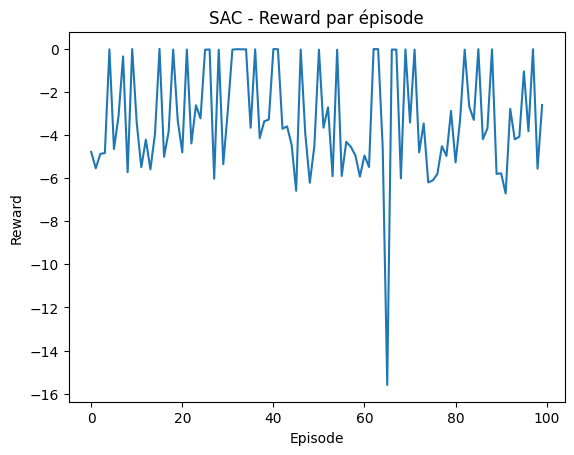

In [8]:
from stable_baselines3.common.evaluation import evaluate_policy
eval_env_final = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
episode_rewards, episode_lengths = evaluate_policy(
    model2, eval_env_final,
    n_eval_episodes=100,
    return_episode_rewards=True
)

import matplotlib.pyplot as plt
plt.plot(episode_rewards)
plt.title("SAC - Reward par épisode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In regards of these results, the SAC algorithm seems also to perform poorly in this task. For the training phase, the expected result would be an overall increase of the sucess rate and a maximization of the reward function as we go on. However, we can see that the overall suces rate oscillates greatly around 30% and presents a significant variance. We can say the same thing of the reward function oscillating around -3 approximately wih a standard deviation of 3. No concergence seems to have been reached during this phase.

When it comes to the testing phase, the obtained values are close to those of the training phase. A huge variance can be observed as the model behaves more or less poorly across the different testing episodes.

Overall, the results are quite the same for the SAC and the PPO algorithm : for the moment the system is not learning. In the case of the SAC, we can say that 100 000 steps is not sufficent for the system to converge. It's not really a surprise because the SAC algorithm is expected to learn much slower than the PPO algorithm but, it should have better results.

We can still notice that the highest percentage rate for the SAC is 80 meanwhile it's 60 for the PPO. It can be luck because it has been reached only two times but for the moment that's the only difference.

Let's try with more steps for the SAC to confirm our hypothesis.

In [14]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import SAC

# we will use the EvalCallback to collect the training data and plot it
# to do so the environment needs to be wrapped in the Monitor environment
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# initializing the environment for the robot
# render mode set to rgb_array because Colab does not support the display
# reward_type set to dense to give the model better insight on the reward,
# proportionally to the distance between pushed object and the target location
env3 = gym.make(
    "PandaPush-v3",
    render_mode="rgb_array",
    reward_type="dense",
)
env3 = Monitor(env3)

# creating a CallBack instance to run some metrics in a separate environment
eval_env3 = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
eval_env3 = Monitor(eval_env3)
eval_callback3 = EvalCallback(
    eval_env3,
    eval_freq=1000,
    n_eval_episodes=5,
    log_path="./logs/",
    best_model_save_path="./best_model/",
    deterministic=True,
    verbose=1,
)

# creating an instance of the PPO algorithm and do training on selected env
model3 = SAC("MultiInputPolicy", env3, verbose=1)
model3.learn(total_timesteps=500000, callback= eval_callback3)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
|    success_rate    | 0.63     |
| time/              |          |
|    episodes        | 13568    |
|    fps             | 27       |
|    time_elapsed    | 17021    |
|    total_timesteps | 473765   |
| train/             |          |
|    actor_loss      | 7.24     |
|    critic_loss     | 0.166    |
|    ent_coef        | 0.00458  |
|    ent_coef_loss   | 1.63     |
|    learning_rate   | 0.0003   |
|    n_updates       | 473664   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.9     |
|    ep_rew_mean     | -2.01    |
|    success_rate    | 0.65     |
| time/              |          |
|    episodes        | 13572    |
|    fps             | 27       |
|    time_elapsed    | 17021    |
|    total_timesteps | 473780   |
| train/             |          |
|    actor_loss      | 7.39     |
|    critic_loss     | 0.248    |
|   

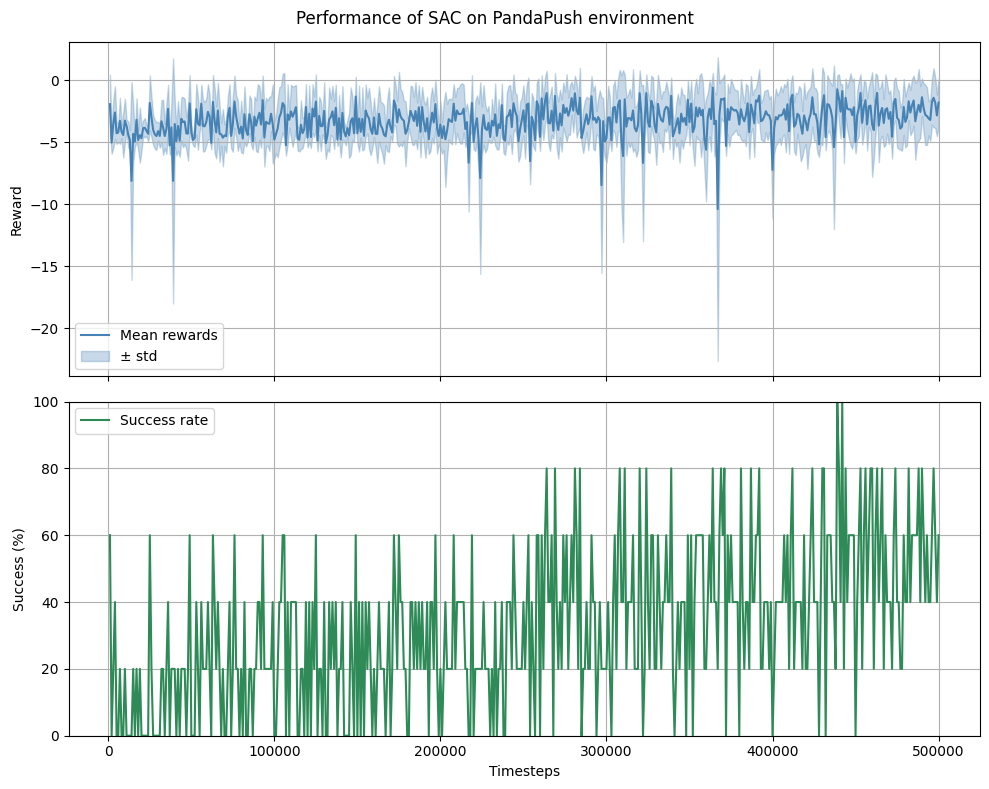

In [15]:
# evaluating the performance of the model during its learning
import numpy as np
import matplotlib.pyplot as plt

# we first extract the relevant arrays:
# one for the steps during which an eval was done
# one for the reward of each evaluation episodes at every step an eval was done
# one for the sucess or not (0 or 1) of tasks during an evaluation at every step
rewards = eval_callback3.evaluations_results
timesteps = eval_callback3.evaluations_timesteps
successes = eval_callback3.evaluations_successes

mean_rewards = np.mean(rewards, axis=1)
std_rewards  = np.std(rewards, axis=1)
mean_success = np.mean(successes, axis=1) * 100  # % of sucess in an evaluation

# plotting code
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Rewards are collected for each evaluation episode for each step (2d array)
# to do an easy to visualize plot, we can display mean and standard deviation
ax1.plot(timesteps, mean_rewards, color="steelblue", label="Mean rewards")
ax1.fill_between(timesteps,
                 mean_rewards - std_rewards,
                 mean_rewards + std_rewards,
                 alpha=0.3, color="steelblue", label="± std")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# Success rate
ax2.plot(timesteps, mean_success, color="seagreen", label="Success rate")
ax2.set_ylabel("Success (%)")
ax2.set_xlabel("Timesteps")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.suptitle("Performance of SAC on PandaPush environment")
plt.tight_layout()
plt.show()

In [16]:
def evaluate(model, n_episodes=100, deterministic=True, env_type="source"):
    env = gym.make("PandaPush-v3", render_mode="rgb_array", type=env_type, reward_type="dense")

    episode_returns = []
    successes = []
    for episode in range(1, n_episodes + 1):
        obs, info = env.reset()
        terminated = False
        truncated = False
        episode_return = 0.0
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)
        episode_returns.append(episode_return)
        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))
        print(f"Episode {episode:03d} | return = {episode_return:.3f}")
    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes       : {n_episodes}")
    print(f"Mean return    : {returns.mean():.3f}")
    print(f"Std return     : {returns.std():.3f}")
    print(f"Min return     : {returns.min():.3f}")
    print(f"Max return     : {returns.max():.3f}")
    if successes:
        print(f"Success rate   : {float(np.mean(successes)):.2%}")

evaluate(model3, n_episodes=100, deterministic=True, env_type="source")

Created object with mass: 1.0
Episode 001 | return = -0.938
Episode 002 | return = -8.807
Episode 003 | return = -0.428
Episode 004 | return = -0.362
Episode 005 | return = -1.092
Episode 006 | return = -0.757
Episode 007 | return = -6.263
Episode 008 | return = -0.033
Episode 009 | return = -0.524
Episode 010 | return = -0.036
Episode 011 | return = -0.042
Episode 012 | return = -0.524
Episode 013 | return = -0.652
Episode 014 | return = -0.018
Episode 015 | return = -0.266
Episode 016 | return = -1.782
Episode 017 | return = -3.647
Episode 018 | return = -0.303
Episode 019 | return = -2.250
Episode 020 | return = -0.045
Episode 021 | return = -2.616
Episode 022 | return = -0.955
Episode 023 | return = -0.286
Episode 024 | return = -6.076
Episode 025 | return = -0.714
Episode 026 | return = -0.032
Episode 027 | return = -0.222
Episode 028 | return = -4.256
Episode 029 | return = -3.786
Episode 030 | return = -3.890
Episode 031 | return = -0.877
Episode 032 | return = -0.686
Episode 03

Created object with mass: 1.0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


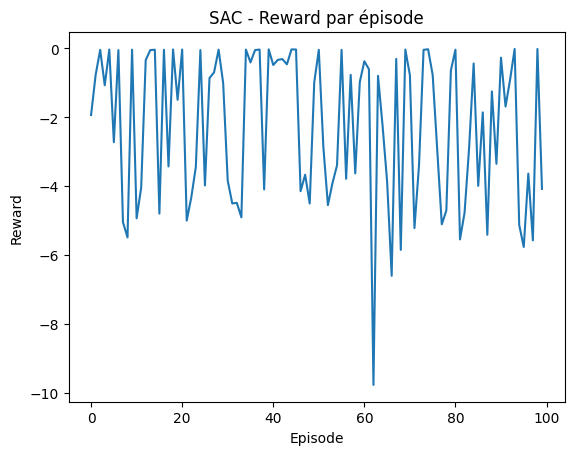

In [17]:
from stable_baselines3.common.evaluation import evaluate_policy
eval_env_final = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
episode_rewards, episode_lengths = evaluate_policy(
    model3, eval_env_final,
    n_eval_episodes=100,
    return_episode_rewards=True
)

import matplotlib.pyplot as plt
plt.plot(episode_rewards)
plt.title("SAC - Reward par épisode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [4]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import SAC

from google.colab import drive
drive.mount('/content/drive')

# we will use the EvalCallback to collect the training data and plot it
# to do so the environment needs to be wrapped in the Monitor environment
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# initializing the environment for the robot
# render mode set to rgb_array because Colab does not support the display
# reward_type set to dense to give the model better insight on the reward,
# proportionally to the distance between pushed object and the target location
env4 = gym.make(
    "PandaPush-v3",
    render_mode="rgb_array",
    reward_type="dense",
)
env4 = Monitor(env4)

# creating a CallBack instance to run some metrics in a separate environment
eval_env4 = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
eval_env4 = Monitor(eval_env4)
eval_callback4 = EvalCallback(
    eval_env4,
    eval_freq=1000,
    n_eval_episodes=5,
    log_path="./logs/",
    best_model_save_path="./best_model/",
    deterministic=True,
    verbose=1,
)

# creating an instance of the PPO algorithm and do training on selected env
model4 = SAC("MultiInputPolicy", env4, verbose=1)
model4.learn(total_timesteps=1000000, callback= eval_callback4)

model4.save("/content/drive/MyDrive/RL_models/sac_panda_final")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
|    episodes        | 27060    |
|    fps             | 26       |
|    time_elapsed    | 36187    |
|    total_timesteps | 974755   |
| train/             |          |
|    actor_loss      | 7.27     |
|    critic_loss     | 0.0904   |
|    ent_coef        | 0.00295  |
|    ent_coef_loss   | -0.517   |
|    learning_rate   | 0.0003   |
|    n_updates       | 974654   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 26       |
|    ep_rew_mean     | -2.18    |
|    success_rate    | 0.56     |
| time/              |          |
|    episodes        | 27064    |
|    fps             | 26       |
|    time_elapsed    | 36189    |
|    total_timesteps | 974817   |
| train/             |          |
|    actor_loss      | 7.61     |
|    critic_loss     | 0.171    |
|    ent_coef        | 0.00292  |
|    ent_coef_loss   | -1.71    |
|   

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path '/content/drive/MyDrive/RL_models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


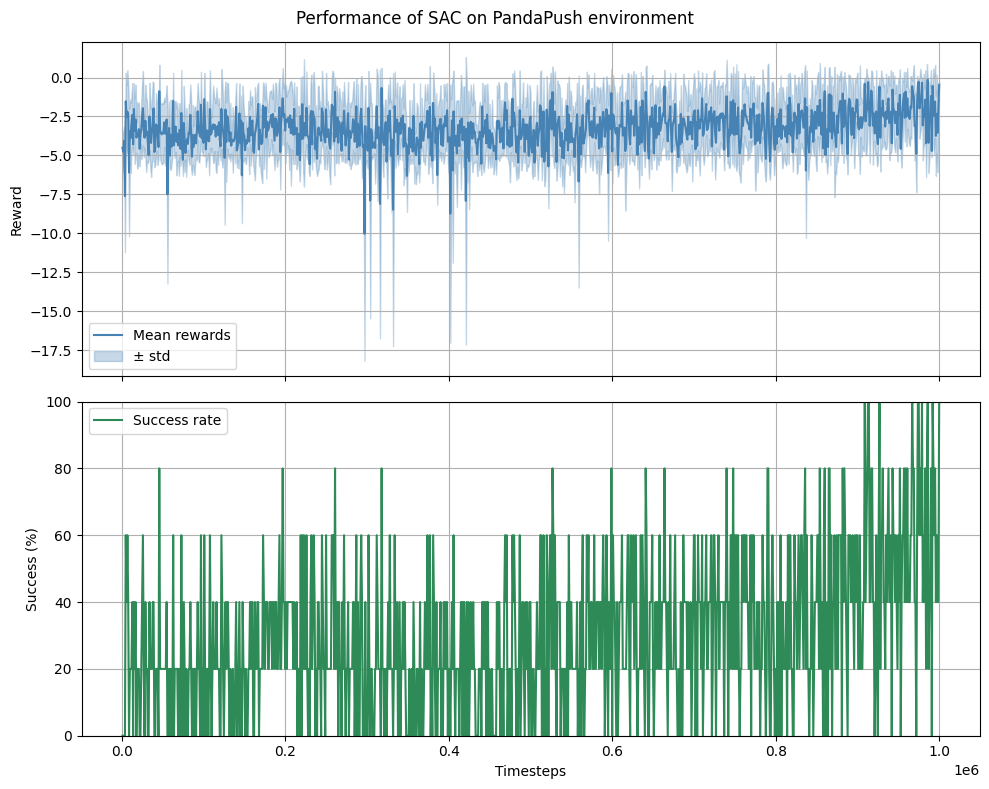

In [5]:
# evaluating the performance of the model during its learning
import numpy as np
import matplotlib.pyplot as plt

# we first extract the relevant arrays:
# one for the steps during which an eval was done
# one for the reward of each evaluation episodes at every step an eval was done
# one for the sucess or not (0 or 1) of tasks during an evaluation at every step
rewards = eval_callback4.evaluations_results
timesteps = eval_callback4.evaluations_timesteps
successes = eval_callback4.evaluations_successes

mean_rewards = np.mean(rewards, axis=1)
std_rewards  = np.std(rewards, axis=1)
mean_success = np.mean(successes, axis=1) * 100  # % of sucess in an evaluation

# plotting code
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Rewards are collected for each evaluation episode for each step (2d array)
# to do an easy to visualize plot, we can display mean and standard deviation
ax1.plot(timesteps, mean_rewards, color="steelblue", label="Mean rewards")
ax1.fill_between(timesteps,
                 mean_rewards - std_rewards,
                 mean_rewards + std_rewards,
                 alpha=0.3, color="steelblue", label="± std")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# Success rate
ax2.plot(timesteps, mean_success, color="seagreen", label="Success rate")
ax2.set_ylabel("Success (%)")
ax2.set_xlabel("Timesteps")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

plt.suptitle("Performance of SAC on PandaPush environment")
plt.tight_layout()
plt.show()

In [6]:
def evaluate(model, n_episodes=100, deterministic=True, env_type="source"):
    env = gym.make("PandaPush-v3", render_mode="rgb_array", type=env_type, reward_type="dense")

    episode_returns = []
    successes = []
    for episode in range(1, n_episodes + 1):
        obs, info = env.reset()
        terminated = False
        truncated = False
        episode_return = 0.0
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_return += float(reward)
        episode_returns.append(episode_return)
        if isinstance(info, dict) and "is_success" in info:
            successes.append(float(info["is_success"]))
        print(f"Episode {episode:03d} | return = {episode_return:.3f}")
    env.close()

    returns = np.array(episode_returns, dtype=np.float32)
    print("\n=== Evaluation summary ===")
    print(f"Episodes       : {n_episodes}")
    print(f"Mean return    : {returns.mean():.3f}")
    print(f"Std return     : {returns.std():.3f}")
    print(f"Min return     : {returns.min():.3f}")
    print(f"Max return     : {returns.max():.3f}")
    if successes:
        print(f"Success rate   : {float(np.mean(successes)):.2%}")

evaluate(model4, n_episodes=100, deterministic=True, env_type="source")

Created object with mass: 1.0
Episode 001 | return = -0.015
Episode 002 | return = -0.231
Episode 003 | return = -0.016
Episode 004 | return = -0.463
Episode 005 | return = -0.043
Episode 006 | return = -0.638
Episode 007 | return = -0.674
Episode 008 | return = -3.886
Episode 009 | return = -0.032
Episode 010 | return = -0.025
Episode 011 | return = -0.692
Episode 012 | return = -0.511
Episode 013 | return = -4.878
Episode 014 | return = -0.437
Episode 015 | return = -0.821
Episode 016 | return = -0.043
Episode 017 | return = -3.051
Episode 018 | return = -0.229
Episode 019 | return = -0.319
Episode 020 | return = -3.225
Episode 021 | return = -4.164
Episode 022 | return = -0.499
Episode 023 | return = -4.344
Episode 024 | return = -3.690
Episode 025 | return = -2.986
Episode 026 | return = -6.495
Episode 027 | return = -0.311
Episode 028 | return = -0.261
Episode 029 | return = -0.044
Episode 030 | return = -4.922
Episode 031 | return = -0.017
Episode 032 | return = -0.695
Episode 03

Created object with mass: 1.0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


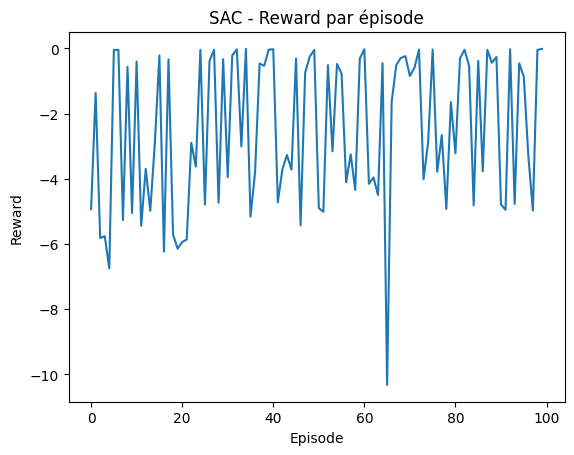

In [7]:
from stable_baselines3.common.evaluation import evaluate_policy
eval_env_final = gym.make("PandaPush-v3", render_mode="rgb_array", reward_type="dense")
episode_rewards, episode_lengths = evaluate_policy(
    model4, eval_env_final,
    n_eval_episodes=100,
    return_episode_rewards=True
)

import matplotlib.pyplot as plt
plt.plot(episode_rewards)
plt.title("SAC - Reward par épisode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()